In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from parameterrun import parameterrun
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
from solve_pulses import compute_degradation, solve_CRAB, solve_gq, solve_GRAPE

import geodesiq as gq

# Landau-Zener

In [2]:
# ----- Define ControlModel -----
def hamiltonian_LZ(z, x):
    return np.array([[z, x], [x, -z]])


n_ts = 50  # time slices
amp_lbound, amp_ubound = -10.0, 10.0
x = 1
tf = 20

H_initial = qt.Qobj(hamiltonian_LZ(amp_lbound, x))
H_final = qt.Qobj(hamiltonian_LZ(amp_ubound, x))

index_0 = 0
index_t = 0

psi0 = H_initial.eigenstates()[1][index_0]
psit = H_final.eigenstates()[1][index_t]

H_c = qt.Qobj(hamiltonian_LZ(1, 0))
H_d = qt.Qobj(hamiltonian_LZ(0, x))

# fid_err_targ = 1 - np.sqrt(1 - 1e-6)
fid_err_targ = 2e-7
print(f"{fid_err_targ=}")

fid_err_targ=2e-07


In [20]:
model = gq.ControlModel(H_c=H_c[:], H_d=H_d[:])
model.set_control(
    control_name="z",
    pulse_initial=amp_lbound,
    pulse_final=amp_ubound,
    initial_state=index_0,
    alpha=0,
    beta=0,
    num_steps=n_ts,
)

energies = model.eigenenergies.real
z_vals = model._control_pulse

In [3]:
grape_time, grape_pulse = solve_GRAPE(
    H_c,
    H_d,
    psi0,
    psit,
    tf,
    n_ts,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    init_amps=np.linspace(amp_lbound, amp_ubound, n_ts),
    samples_per_slot=40,
    verbose=True,
)

goal: True
error: 1.892460932406692e-08
reason: Goal achieved
initial: -10.0
final: 10.0


In [4]:
grape_time_random, grape_pulse_random = solve_GRAPE(
    H_c,
    H_d,
    psi0,
    psit,
    tf,
    n_ts,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    init_amps=np.random.rand(n_ts),
    samples_per_slot=40,
    verbose=True,
)

goal: True
error: 6.731111557023439e-09
reason: Goal achieved
initial: -9.997915611674786
final: 9.99828756322417


In [5]:
crab_time, crab_pulse = solve_CRAB(
    H_c,
    H_d,
    psi0,
    psit,
    tf,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    num_tslots=1000,
    n_super_iterations=10,
    num_coeffs=10,
    correction_scale=0.1,
    print_every=40,
    verbose=True,
)

goal: Trueation 1/10 finished | error = 1.892946e-07 | global best = 1.892946e-07-07
error: 1.8929457379357473e-07
reason: Goal achieved


In [6]:
alpha = 1
beta = 1

gq_time, gq_pulse = solve_gq(
    H_c,
    H_d,
    tf,
    index_0,
    alpha,
    beta,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    n_ts=2**10 + 1,
    verbose=True,
)

goal: False
error: 2.2955229994625626e-07


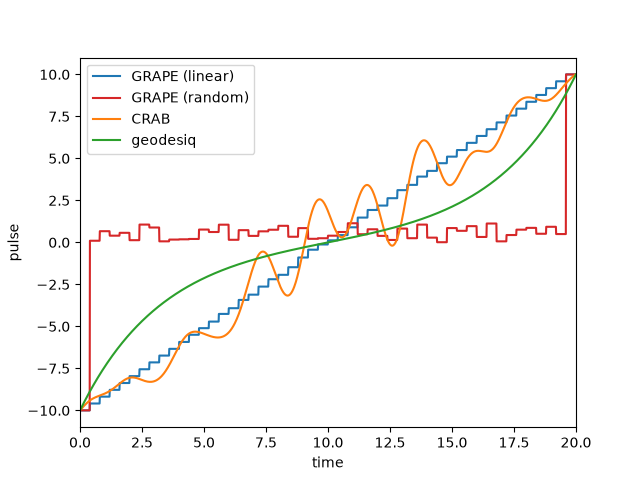

In [7]:
fig, ax = plt.subplots()

ax.plot(grape_time, grape_pulse, c="C0", label="GRAPE (linear)")
ax.plot(grape_time_random, grape_pulse_random, c="C3", label="GRAPE (random)")
ax.plot(crab_time, crab_pulse, c="C1", label="CRAB")
ax.plot(gq_time, gq_pulse, c="C2", label="geodesiq")

ax.legend()
ax.set_xlabel("time")
ax.set_xlim(0, tf)
ax.set_ylabel("pulse");

## Filter pulses

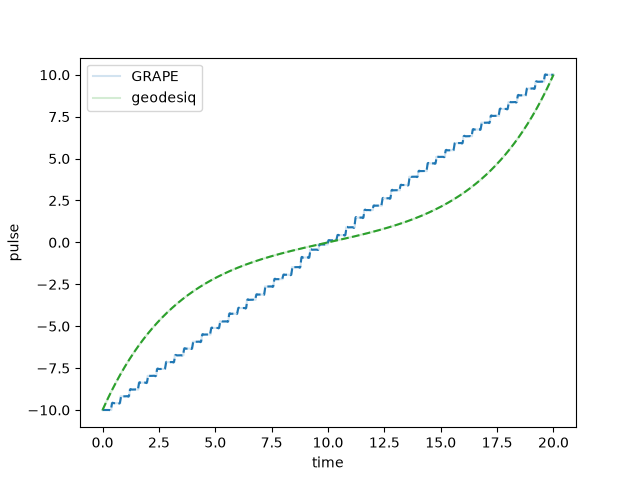

In [8]:
# f_cut = np.log10(0.1)
f_cut = 9.9

grape_filtered = gq.PulseControl(grape_pulse, grape_time[-1]).filtered_pulse(cutoff_freq=f_cut)[1]
gp_filtered = gq.PulseControl(gq_pulse, gq_time[-1]).filtered_pulse(cutoff_freq=f_cut)[1]

fig, ax = plt.subplots()
ax.plot(grape_time, grape_pulse, c="C0", alpha=0.2, label="GRAPE")
ax.plot(grape_time, grape_filtered, c="C0", ls="--")

ax.plot(gq_time, gq_pulse, c="C2", alpha=0.2, label="geodesiq")
ax.plot(gq_time, gp_filtered, c="C2", ls="--")

ax.set_xlabel("time")
ax.set_ylabel("pulse")
ax.legend();

In [9]:
cutoffs = np.logspace(-0.5, np.log10(9.98), 200)

fidelities_gq = np.asanyarray(
    parameterrun(
        compute_degradation, "cutoff", cutoffs, time=gq_time, pulse=gq_pulse, H_d=H_d, H_c=H_c, psi0=psi0, psit=psit
    )
)
fidelities_GRAPE = np.asanyarray(
    parameterrun(
        compute_degradation,
        "cutoff",
        cutoffs,
        time=grape_time,
        pulse=grape_pulse,
        H_d=H_d,
        H_c=H_c,
        psi0=psi0,
        psit=psit,
    )
)
fidelities_GRAPE_random = np.asanyarray(
    parameterrun(
        compute_degradation,
        "cutoff",
        cutoffs,
        time=grape_time_random,
        pulse=grape_pulse_random,
        H_d=H_d,
        H_c=H_c,
        psi0=psi0,
        psit=psit,
    )
)
fidelities_CRAB = np.asanyarray(
    parameterrun(
        compute_degradation, "cutoff", cutoffs, time=crab_time, pulse=crab_pulse, H_d=H_d, H_c=H_c, psi0=psi0, psit=psit
    )
)

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

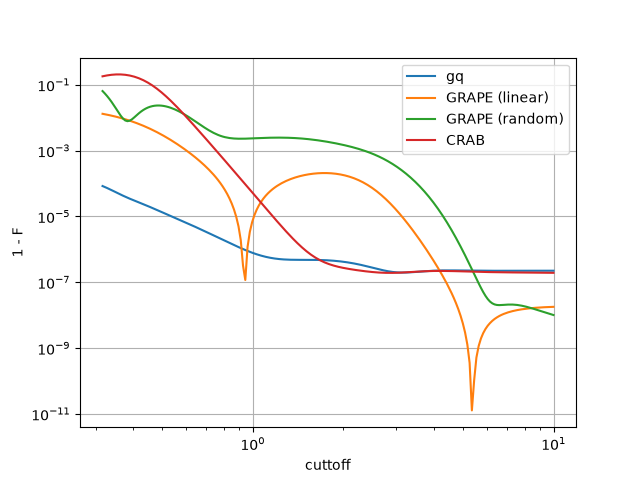

In [10]:
fig, ax = plt.subplots()

ax.plot(cutoffs, 1 - np.sqrt(fidelities_gq), label="gq")
ax.plot(cutoffs, 1 - np.sqrt(fidelities_GRAPE), label="GRAPE (linear)")
ax.plot(cutoffs, 1 - np.sqrt(fidelities_GRAPE_random), label="GRAPE (random)")
ax.plot(cutoffs, 1 - np.sqrt(fidelities_CRAB), label="CRAB")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("cuttoff")
ax.set_ylabel("1 - F")
ax.legend()
ax.grid();

In [21]:
np.savez(
    "data/LZ_results.npz",
    z_vals=z_vals,
    energies=energies,
    grape_time=grape_time,
    grape_pulse=grape_pulse,
    crab_time=crab_time,
    crab_pulse=crab_pulse,
    grape_time_random=grape_time_random,
    grape_pulse_random=grape_pulse_random,
    gq_time=gq_time,
    gq_pulse=gq_pulse,
    cutoffs=cutoffs,
    fidelities_gq=fidelities_gq,
    fidelities_GRAPE=fidelities_GRAPE,
    fidelities_GRAPE_random=fidelities_GRAPE_random,
    fidelities_CRAB=fidelities_CRAB,
)

# Ising model

In [23]:
def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising ControlModel with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i + 1] for i in range(L - 1)]
    z_list = [[lam * hz, i] for i in range(L)]
    x_list = [[(1 - lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return H.toarray()


def ising_model_derivative(lam, L, hx, hz):
    zz_list = [[1.0, i, i + 1] for i in range(L - 1)]
    z_list = [[hz, i] for i in range(L)]
    x_list = [[-hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    dH = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return dH.toarray()


L, hx, hz = 4, 1, 0.8
# L, hx, hz = 4, 0.5, .8
# n_ts = 50  # time slices
n_ts = 2**6 + 1
amp_lbound, amp_ubound = 0.1, 0.9
tf = 250
# tf = 300

alpha = 2
beta = 2

H_initial = qt.Qobj(ising_model(amp_lbound, L, hx, hz))
H_final = qt.Qobj(ising_model(amp_ubound, L, hx, hz))

index_0 = 6
index_t = 6

psi0 = H_initial.eigenstates()[1][index_0]
psit = H_final.eigenstates()[1][index_t]

# fid_err_targ = 1 - np.sqrt(1 - 1e-3)
# fid_err_targ = 0.0003
fid_err_targ = 0.00031
print(f"{fid_err_targ=}")

H_d = qt.Qobj(ising_model(0, L, hx, hz))
H_c = qt.Qobj(ising_model(1, L, hx, hz)) - H_d

fid_err_targ=0.00031


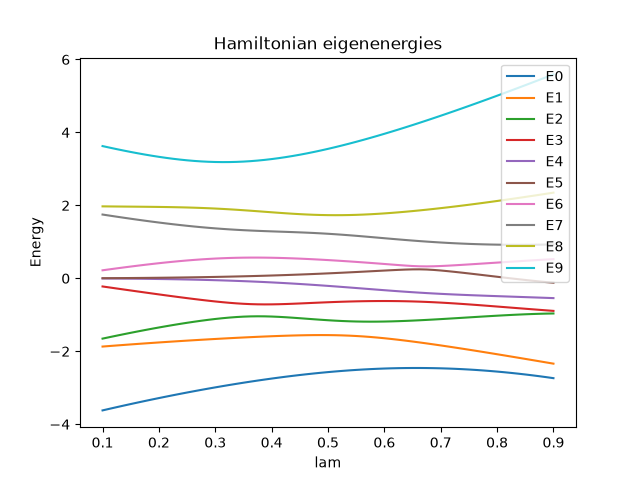

In [26]:
tfs = np.linspace(0.1, tf, 100)

model = gq.ControlModel(H_c=H_c[:], H_d=H_d[:])
model.set_control(
    control_name="lam",
    pulse_initial=amp_lbound,
    pulse_final=amp_ubound,
    initial_state=index_0,
    alpha=alpha,
    beta=beta,
    num_steps=n_ts,
)

model.plot_eigenvalues()

energies = model.eigenenergies.real
lam_vals = model._control_pulse

In [28]:
grape_time, grape_pulse = solve_GRAPE(
    H_c,
    H_d,
    psi0,
    psit,
    tf,
    n_ts,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    init_amps=np.linspace(amp_lbound, amp_ubound, n_ts),
    samples_per_slot=40,
    verbose=True,
)

goal: True
error: 0.00019686353359993358
reason: Goal achieved
initial: 0.1001656721840982
final: 0.8949356244675102


In [29]:
grape_time_random, grape_pulse_random = solve_GRAPE(
    H_c,
    H_d,
    psi0,
    psit,
    tf,
    n_ts,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    init_amps=np.random.rand(n_ts),
    samples_per_slot=40,
    verbose=True,
)

goal: True
error: 0.00010690598232165893
reason: Goal achieved
initial: 0.1
final: 0.8972759933664434


In [30]:
crab_time, crab_pulse = solve_CRAB(
    H_c,
    H_d,
    psi0,
    psit,
    tf,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    num_tslots=1000,
    n_super_iterations=10,
    num_coeffs=10,
    correction_scale=0.1,
    print_every=40,
    verbose=True,
)

goal: Trueation 1/10 finished | error = 3.052791e-04 | global best = 3.052791e-04-04
error: 0.0003052790633601976
reason: Goal achieved


In [31]:
gq_time, gq_pulse = solve_gq(
    H_c,
    H_d,
    tf,
    index_0,
    alpha,
    beta,
    amp_lbound,
    amp_ubound,
    fid_err_targ,
    n_ts=n_ts,
    verbose=True,
)

goal: True
error: 0.0002824067312529044


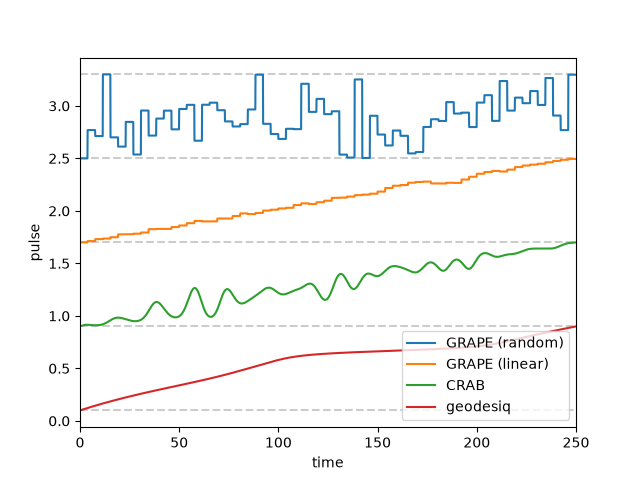

In [32]:
fig, ax = plt.subplots()

shift = (amp_ubound - amp_lbound) + 0.0

ax.plot(grape_time_random, grape_pulse_random + shift * 3, c="C0", label="GRAPE (random)")
ax.plot(grape_time, grape_pulse + shift * 2, c="C1", label="GRAPE (linear)")
ax.plot(crab_time, crab_pulse + shift * 1, c="C2", label="CRAB")
ax.plot(gq_time, gq_pulse + shift * 0, c="C3", label="geodesiq")

for i in range(5):
    ax.axhline(shift * i + amp_lbound, ls="--", color="k", alpha=0.2, zorder=-1)

ax.legend(loc="lower right")
ax.set_xlabel("time")
ax.set_xlim(0, tf)
ax.set_ylabel("pulse");

## Filter pulses

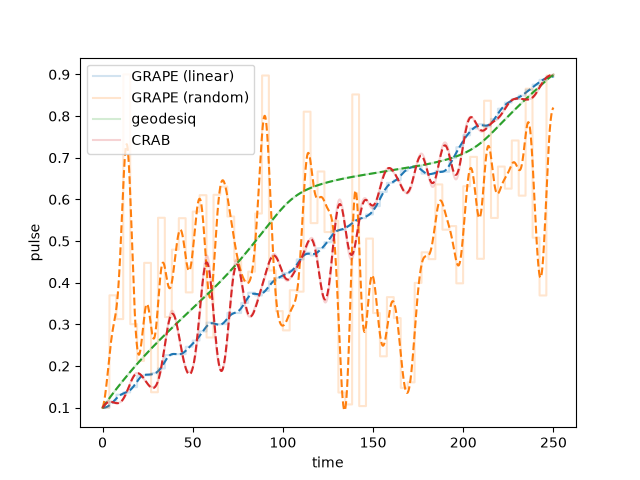

In [33]:
# f_cut = np.log10(0.1)
f_cut = 0.1

grape_filtered_random = gq.PulseControl(grape_pulse_random, grape_time_random[-1]).filtered_pulse(cutoff_freq=f_cut)[1]
grape_filtered = gq.PulseControl(grape_pulse, grape_time[-1]).filtered_pulse(cutoff_freq=f_cut)[1]
gp_filtered = gq.PulseControl(gq_pulse, gq_time[-1]).filtered_pulse(cutoff_freq=f_cut)[1]
crab_filtered = gq.PulseControl(crab_pulse, crab_time[-1]).filtered_pulse(cutoff_freq=f_cut)[1]

fig, ax = plt.subplots()
ax.plot(grape_time, grape_pulse, c="C0", alpha=0.2, label="GRAPE (linear)")
ax.plot(grape_time, grape_filtered, c="C0", ls="--")

ax.plot(grape_time_random, grape_pulse_random, c="C1", alpha=0.2, label="GRAPE (random)")
ax.plot(grape_time_random, grape_filtered_random, c="C1", ls="--")

ax.plot(gq_time, gq_pulse, c="C2", alpha=0.2, label="geodesiq")
ax.plot(gq_time, gp_filtered, c="C2", ls="--")

ax.plot(crab_time, crab_pulse, c="C3", alpha=0.2, label="CRAB")
ax.plot(crab_time, crab_filtered, c="C3", ls="--")

ax.set_xlabel("time")
ax.set_ylabel("pulse")
ax.legend();

In [36]:
# cutoffs = np.logspace(-2, np.log10(3.997), 200)
cutoffs = np.logspace(-2, np.log10(1.997), 200)

fidelities_gq = np.asanyarray(
    parameterrun(
        compute_degradation, "cutoff", cutoffs, time=gq_time, pulse=gq_pulse, H_d=H_d, H_c=H_c, psi0=psi0, psit=psit
    )
)
fidelities_GRAPE = np.asanyarray(
    parameterrun(
        compute_degradation,
        "cutoff",
        cutoffs,
        time=grape_time,
        pulse=grape_pulse,
        H_d=H_d,
        H_c=H_c,
        psi0=psi0,
        psit=psit,
    )
)
fidelities_GRAPE_random = np.asanyarray(
    parameterrun(
        compute_degradation,
        "cutoff",
        cutoffs,
        time=grape_time_random,
        pulse=grape_pulse_random,
        H_d=H_d,
        H_c=H_c,
        psi0=psi0,
        psit=psit,
    )
)
fidelities_CRAB = np.asanyarray(
    parameterrun(
        compute_degradation, "cutoff", cutoffs, time=crab_time, pulse=crab_pulse, H_d=H_d, H_c=H_c, psi0=psi0, psit=psit
    )
)

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

compute_degradation: [['cutoff']]:   0%|          | 0/200 [00:00<?, ?it/s]

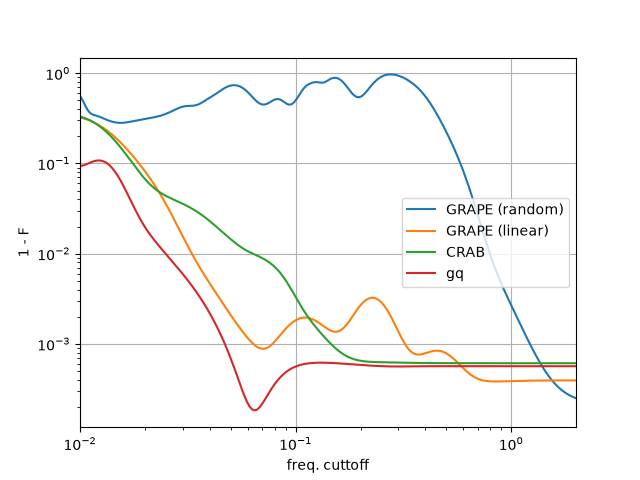

In [37]:
fig, ax = plt.subplots()

ax.plot(cutoffs, 1 - fidelities_GRAPE_random, label="GRAPE (random)")
ax.plot(cutoffs, 1 - fidelities_GRAPE, label="GRAPE (linear)")
ax.plot(cutoffs, 1 - fidelities_CRAB, label="CRAB")
ax.plot(cutoffs, 1 - fidelities_gq, label="gq")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("freq. cuttoff")
ax.set_ylabel("1 - F")
ax.set_xlim(min(cutoffs), max(cutoffs))
ax.legend()
ax.grid()

In [38]:
np.savez(
    "data/many_body_results.npz",
    lam_vals=lam_vals,
    energies=energies,
    grape_time=grape_time,
    grape_pulse=grape_pulse,
    crab_time=crab_time,
    crab_pulse=crab_pulse,
    grape_time_random=grape_time_random,
    grape_pulse_random=grape_pulse_random,
    gq_time=gq_time,
    gq_pulse=gq_pulse,
    cutoffs=cutoffs,
    fidelities_gq=fidelities_gq,
    fidelities_GRAPE=fidelities_GRAPE,
    fidelities_GRAPE_random=fidelities_GRAPE_random,
    fidelities_CRAB=fidelities_CRAB,
)